In [118]:
!pip install yfinance hmmlearn tensorflow scikit-learn


In [119]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input


In [120]:
symbol = "^NSEI"

start = "2010-01-01"
end = datetime.today().strftime("%Y-%m-%d")

df = yf.download(symbol, start=start, end=end)

print("Rows:", len(df))


/tmp/ipython-input-95421095.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Rows: 3958


In [121]:
df["Return"] = df["Close"].pct_change()

df["Volatility"] = df["Return"].rolling(20).std()

df["LogVolume"] = np.log(df["Volume"].replace(0,1))

df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()

df["MA_Diff"] = df["MA20"] - df["MA50"]


# RSI
delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / (avg_loss + 1e-10)

df["RSI"] = 100 - (100/(1+rs))


df = df.replace([np.inf,-np.inf],np.nan)
df = df.dropna()

print("Clean rows:", len(df))


Clean rows: 3909


In [122]:
daily_features = [
    "Return",
    "Volatility",
    "LogVolume",
    "MA_Diff",
    "RSI"
]

X = df[daily_features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [123]:
def train_hmm(X):

    model = GaussianHMM(
        n_components=3,
        covariance_type="diag",
        n_iter=200,
        tol=1e-2,
        min_covar=1e-3,
        random_state=42
    )

    model.fit(X)

    return model


hmm = train_hmm(X_scaled)

df["Regime"] = hmm.predict(X_scaled)


In [124]:
for i in range(3):

    sub = df[df["Regime"]==i]

    print(f"\nRegime {i}")

    print("Mean Return:",
          round(sub["Return"].mean()*100,3), "%")

    print("Vol:",
          round(sub["Volatility"].mean()*100,3), "%")



Regime 0
Mean Return: 0.063 %
Vol: 1.441 %

Regime 1
Mean Return: 0.031 %
Vol: 1.074 %

Regime 2
Mean Return: 0.046 %
Vol: 0.725 %


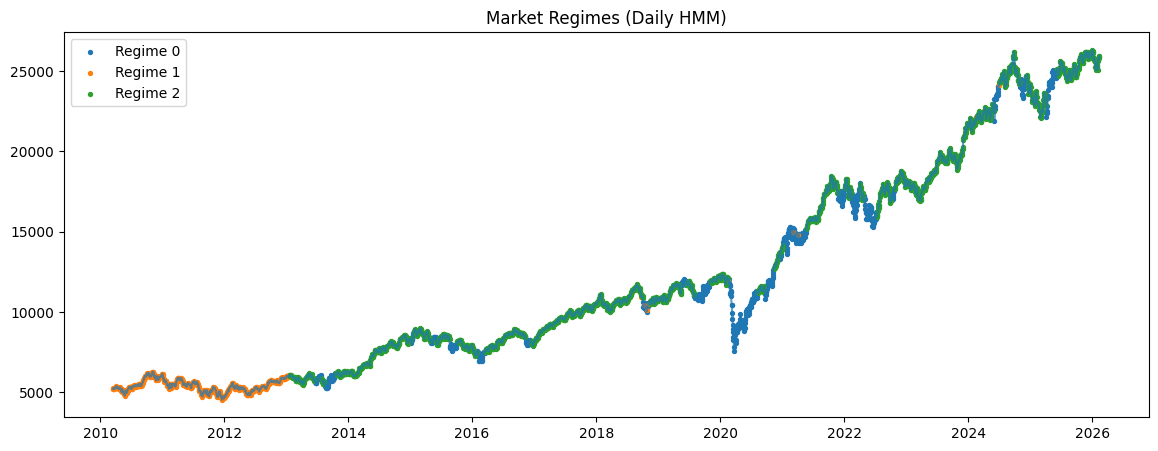

In [125]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df["Close"], alpha=0.7)

for i in range(3):

    idx = df["Regime"]==i

    plt.scatter(
        df.index[idx],
        df["Close"][idx],
        s=8,
        label=f"Regime {i}"
    )

plt.legend()
plt.title("Market Regimes (Daily HMM)")
plt.show()


In [126]:
df["Tomorrow"] = (df["Return"].shift(-1) > 0).astype(int)

df = df.dropna()


In [127]:
def prepare_lstm_data(df, features, window=30):

    X = []
    y = []

    scaler = MinMaxScaler()

    data = scaler.fit_transform(df[features])

    target = df["Tomorrow"].values


    for i in range(window, len(df)):

        X.append(data[i-window:i])
        y.append(target[i])


    return np.array(X), np.array(y), scaler


In [128]:
def build_lstm():

    model = Sequential()

    model.add(Input(shape=(30, len(daily_features))))

    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.3))

    model.add(LSTM(64))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [129]:
lstm_models = {}

window = 30


for r in df["Regime"].unique():

    sub = df[df["Regime"] == r]

    if len(sub) < 300:
        continue


    X_lstm, y_lstm, scaler_lstm = prepare_lstm_data(
        sub, daily_features, window
    )


    model = build_lstm()

    model.fit(
        X_lstm,
        y_lstm,
        epochs=20,
        batch_size=16,
        verbose=0
    )


    lstm_models[r] = (model, scaler_lstm)


In [130]:
def predict_tomorrow():

    r = df["Regime"].iloc[-1]

    if r not in lstm_models:
        return None


    model, scaler = lstm_models[r]


    last = df[daily_features].iloc[-30:].values

    last = scaler.transform(last)

    last = last.reshape(1,30,len(daily_features))


    prob = model.predict(last, verbose=0)[0][0]

    return prob


In [131]:
p = predict_tomorrow()

print("Last Date:", df.index[-1].date())
print("Probability Up:", round(p*100,2), "%")


if p > 0.53:
    print("Signal: BUY")

elif p < 0.47:
    print("Signal: SELL")

else:
    print("Signal: HOLD")


Last Date: 2026-02-12
Probability Up: 52.66 %
Signal: HOLD


In [132]:
def generate_signals():

    signals = []
    dates = []

    bull_regime = 0   # adjust if needed


    for i in range(100, len(df)-1):

        if i % 300 == 0:
            print("Progress:", i)


        sub = df.iloc[:i]

        r = sub["Regime"].iloc[-1]


        if r not in lstm_models:
            signals.append(0)
            dates.append(df.index[i])
            continue


        model, scaler = lstm_models[r]


        last = sub[daily_features].iloc[-30:].values

        last = scaler.transform(last)

        last = last.reshape(1,30,len(daily_features))


        prob = model.predict(last, verbose=0)[0][0]


        if prob > 0.53:
            sig = 1

        elif prob < 0.47:

            if r == bull_regime:
                sig = 0
            else:
                sig = -1

        else:
            sig = 0


        signals.append(sig)
        dates.append(df.index[i])


    return pd.Series(signals, index=dates)


In [133]:
signals = generate_signals()

signals.value_counts()


Progress: 300
Progress: 600
Progress: 900
Progress: 1200
Progress: 1500
Progress: 1800
Progress: 2100
Progress: 2400
Progress: 2700
Progress: 3000
Progress: 3300
Progress: 3600
Progress: 3900


,count
1,2153
0,1655


In [134]:
def backtest(signals, initial_capital=100000):

    capital = initial_capital
    equity = []

    pos = 0

    returns = df["Return"]
    vol = df["Volatility"]


    for date, signal in signals.items():

        if date not in returns.index:
            continue


        ret = returns.loc[date]
        v = vol.loc[date]


        # Stop-loss cap
        ret = np.clip(ret, -0.05, 0.05)


        # Volatility sizing
        size = min(1, 0.02 / (v + 1e-6))


        if pos == 1:
            capital *= (1 + ret * size)

        elif pos == -1:
            capital *= (1 - ret * size)


        pos = signal

        equity.append(capital)


    return pd.Series(equity, index=signals.index)


In [135]:
equity = backtest(signals)

print("Final Capital:", round(equity.iloc[-1],2))
print("Return %:", round((equity.iloc[-1]/100000 -1)*100,2))


Final Capital: 510656.01
Return %: 410.66


In [136]:
def metrics(equity):

    rets = equity.pct_change().dropna()

    sharpe = np.sqrt(252) * rets.mean() / rets.std()

    max_dd = ((equity / equity.cummax()) - 1).min()

    return sharpe, max_dd


sharpe, dd = metrics(equity)

print("Sharpe Ratio:", round(sharpe,2))
print("Max Drawdown:", round(dd*100,2), "%")


Sharpe Ratio: 1.02
Max Drawdown: -23.29 %


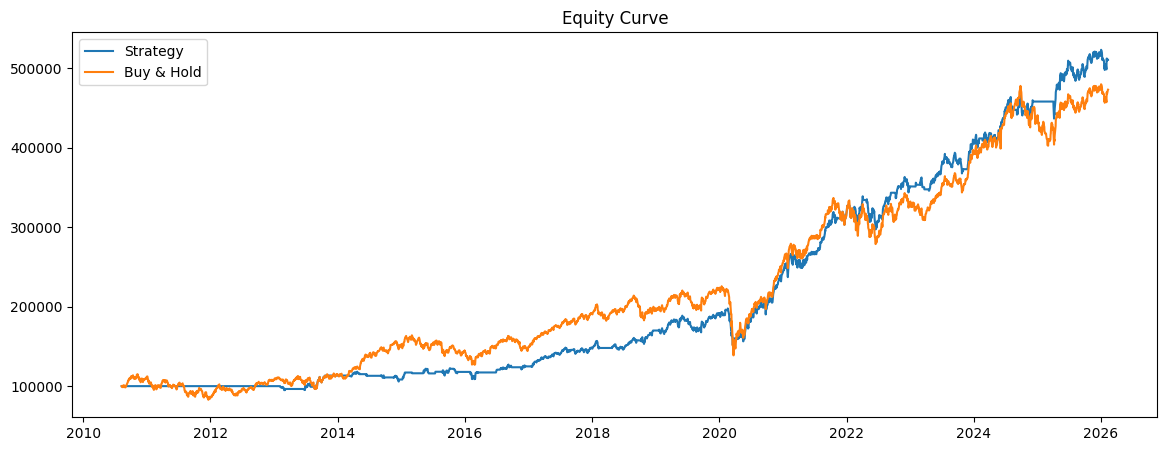

In [150]:
plt.figure(figsize=(14,5))

plt.plot(equity, label="Strategy")


bh = df.loc[equity.index]["Close"]
bh = bh / bh.iloc[0] * 100000

plt.plot(bh, label="Buy & Hold", alpha=1.0)


plt.legend()
plt.title("Equity Curve")
plt.show()


In [138]:
strategy_returns = equity.pct_change().dropna()


In [143]:
def monte_carlo(returns, n_sim=10000, n_days=252):

    sims = []

    for _ in range(n_sim):

        sim = np.random.choice(
            returns,
            size=n_days,
            replace=True
        )

        path = (1+sim).cumprod()

        sims.append(path)


    return np.array(sims)


In [142]:
mc = monte_carlo(strategy_returns)


In [141]:
final_vals = mc[:,-1]

print("Worst Case:", round(np.percentile(final_vals,5),2))
print("Median:", round(np.median(final_vals),2))
print("Best Case:", round(np.percentile(final_vals,95),2))

loss_prob = np.mean(final_vals < 1)

print("Loss Probability:", round(loss_prob*100,2), "%")


Worst Case: 0.93
Median: 1.11
Best Case: 1.34
Loss Probability: 17.15 %


===== Monte Carlo Risk Summary (1 Year) =====
Worst Case (5%)   : 0.926
Median Outcome   : 1.114
Best Case (95%)   : 1.343
Loss Probability : 16.35%



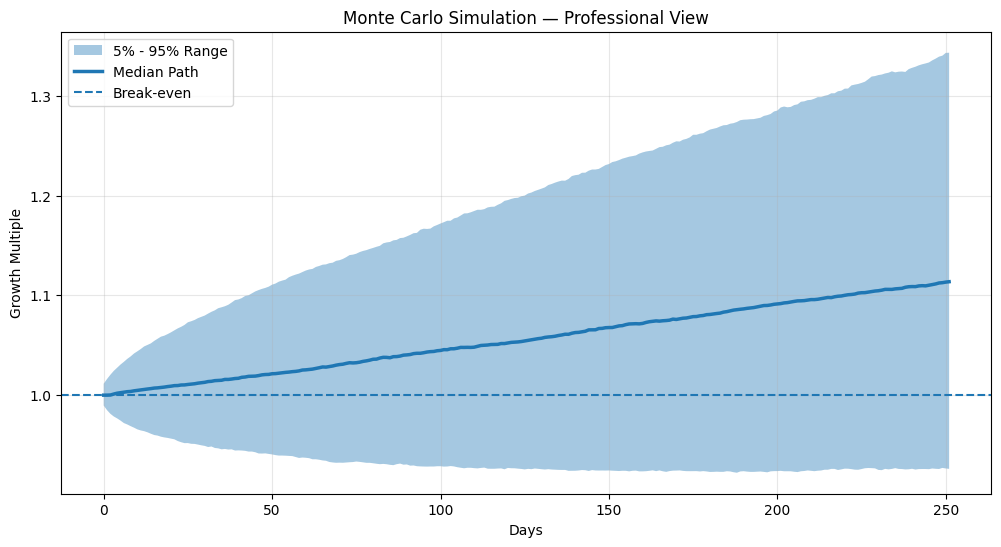

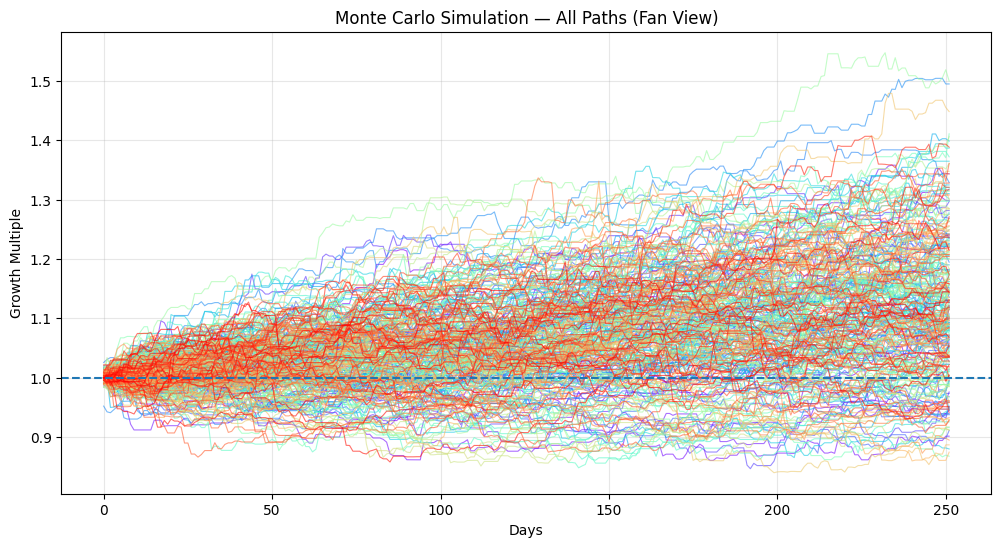

In [153]:
# ================================
# MONTE CARLO FULL VISUALIZATION
# ================================

# ---- Percentile Paths ----
p5 = np.percentile(mc, 5, axis=0)
p50 = np.percentile(mc, 50, axis=0)
p95 = np.percentile(mc, 95, axis=0)

# ---- Final Values ----
final_vals = mc[:, -1]

worst = np.percentile(final_vals, 5)
median = np.percentile(final_vals, 50)
best = np.percentile(final_vals, 95)
loss_prob = np.mean(final_vals < 1) * 100


# ---- Print Numbers ----
print("===== Monte Carlo Risk Summary (1 Year) =====")
print(f"Worst Case (5%)   : {worst:.3f}")
print(f"Median Outcome   : {median:.3f}")
print(f"Best Case (95%)   : {best:.3f}")
print(f"Loss Probability : {loss_prob:.2f}%")
print("=============================================\n")


# =====================================================
# GRAPH 1 — PROFESSIONAL VIEW (BAND + MEDIAN)
# =====================================================

plt.figure(figsize=(12,6))

plt.fill_between(
    range(len(p50)),
    p5,
    p95,
    alpha=0.4,
    label="5% - 95% Range"
)

plt.plot(
    p50,
    linewidth=2.5,
    label="Median Path"
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1.5,
    label="Break-even"
)

plt.title("Monte Carlo Simulation — Professional View")
plt.xlabel("Days")
plt.ylabel("Growth Multiple")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# =====================================================
# GRAPH 2 — ALL PATHS (RAINBOW / FAN VIEW)
# =====================================================

plt.figure(figsize=(12,6))

num_paths = min(300, len(mc))   # limit for clarity

colors = plt.cm.rainbow(np.linspace(0, 1, num_paths))

for i in range(num_paths):

    plt.plot(
        mc[i],
        color=colors[i],
        alpha=0.6,
        linewidth=0.8
    )


plt.axhline(
    1,
    linestyle="--",
    linewidth=1.5
)

plt.title("Monte Carlo Simulation — All Paths (Fan View)")
plt.xlabel("Days")
plt.ylabel("Growth Multiple")

plt.grid(alpha=0.3)

plt.show()

